<a href="https://colab.research.google.com/github/Faheemmalla/heart-disease-prediction/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import numpy as np
import pandas as pd


##Dataset

In [111]:
data = pd.read_csv("heart.csv")

In [112]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [113]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


#Droping Duplicate Values if any

In [114]:
data_dup = data.duplicated().any()
data_dup

np.True_

In [115]:
#droped using this function
data = data.drop_duplicates()


In [116]:
data_dup = data.duplicated().any()
data_dup

np.False_

##Data Preprocessing

In [117]:
cate_val = []
cont_val = []
for column in data.columns:
    if data[column].nunique() <= 10:
        cate_val.append(column)
    else:
        cont_val.append(column)
print("Categorical Columns:", cate_val)
print("Continuous Columns:", cont_val)
#basically what i did is i check each and every column and check using nunique function ki agr kisse column mai
#values less than 10 hai toh most probabily wo catagoy wala hai like gender only 2 unique
# fir inhee ko alag alag krke doo column bana diya

Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
Continuous Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


##Encoding Catagorical Data

In [118]:
data['cp'].unique()

array([0, 1, 2, 3])

In [119]:
data['sex'].unique()

array([1, 0])

In [120]:
#auppar mai column wise dhek raha ki kisme kitne uniques hai for examples
#sex mai sirf 0 ya 1 yaane mail ya female
#see auppar cp has 4 types so it will be converted into 4
#columns taaki model samaj paaye warna wo iesko ghalat read karega

In [121]:
#for sex and target we dont need columns beacuse ienmai sirf two hai either 0 ya 1 ,
#more than 2 than we do , so we remove these two
#we will use dummy vals

In [122]:
cate_val.remove('sex')
cate_val.remove('target')

In [123]:
# Converts categorical columns into numeric (0/1) using one-hot encoding
# drop_first=True removes one category to avoid multicollinearity (dummy variable trap)
# So for n categories, only n-1 columns are created (e.g., cp → 2 columns instead of 3)
#common sense se dhek bhai agr c1 = 0 , c2 = 0 yaane wo c3 he hoga isseliye we will only c1 c2 kyu ki c3 ka inhee se
#pata lag jaayega

In [124]:
data = pd.get_dummies(data, columns=cate_val, drop_first=True)
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [125]:
data = data.astype(int) #true false k badle 0 and 1
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
1,53,1,140,203,155,3,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,70,1,145,174,125,2,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,61,1,148,203,161,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
4,62,0,138,294,106,1,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0


##Feature scaling

In [126]:
from sklearn.preprocessing import StandardScaler

In [127]:
st = StandardScaler()
data[cont_val] = st.fit_transform(data[cont_val])
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,0.216620,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
1,-0.157260,1,0.478910,-0.841918,0.237495,2.085738,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,1.724733,1,0.764066,-1.403197,-1.074521,1.151179,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0.728383,1,0.935159,-0.841918,0.499898,-0.717939,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
4,0.839089,0,0.364848,0.919336,-1.905464,0.216620,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0


#Spliting Into Training and Testing

In [128]:
X = data.drop('target',axis=1)
y = data['target']

In [129]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##LogisticRegression

In [130]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [131]:
y_pred1 = log.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred1)

0.7868852459016393

#SVM

In [132]:
from sklearn import svm
svm = svm.SVC()
svm.fit(X_train,y_train)
y_pred2 = svm.predict(X_test)
accuracy_score(y_test,y_pred2)

0.8032786885245902

#KNN(KNearstNeighbour)

In [133]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred3 = knn.predict(X_test)
accuracy_score(y_test,y_pred3)

0.7377049180327869

In [134]:
score = []

for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    score.append(accuracy_score(y_test, y_pred))

In [138]:
score

[0.7377049180327869,
 0.7868852459016393,
 0.7377049180327869,
 0.7540983606557377,
 0.7377049180327869,
 0.7868852459016393,
 0.7377049180327869,
 0.7868852459016393,
 0.7704918032786885,
 0.7540983606557377,
 0.7540983606557377,
 0.7540983606557377,
 0.7540983606557377,
 0.7704918032786885,
 0.7377049180327869,
 0.8032786885245902,
 0.7704918032786885,
 0.7704918032786885,
 0.7704918032786885,
 0.7704918032786885,
 0.7213114754098361,
 0.7540983606557377,
 0.7377049180327869,
 0.7540983606557377,
 0.7049180327868853,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7213114754098361,
 0.7213114754098361,
 0.7213114754098361,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7213114754098361]

In [140]:
#here we are geeting good acuracy when k is 2 so we do this
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.7868852459016393

In [142]:
final_data = pd.DataFrame({
    'Models': ['LR', 'SVM', 'KNN'],
    'ACC': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ]
})

In [143]:
final_data

,Models,ACC
0,LR,0.786885
1,SVM,0.803279
2,KNN,0.786885


<Axes: xlabel='Models', ylabel='ACC'>

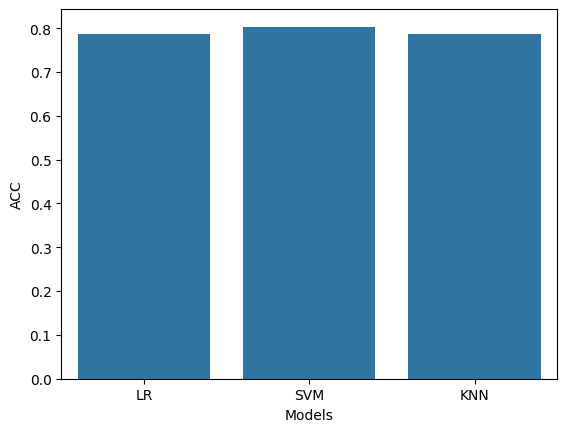

In [146]:
import seaborn as sns
sns.barplot(x=final_data['Models'], y=final_data['ACC'])